# Data & Recovery

**Perishable Demand Forecasting & Zero-Waste Inventory Engine** - FreshRetailNet-50K.

All logic lives in `src/`; this notebook drives it.

| Step | What it does |
|---|---|
| 1 | load the data (builds the subset only if it is missing) |
| 2 | baselines on recorded sales - the bar to clear |
| 3 | compare demand-recovery models and pick one |
| 4 | run the winner and save the recovered demand |
| 5 | checks: did it behave, and did anything leak |

The one fact everything rests on: **a sold-out shelf recording zero sales is not zero demand.**
The till under-counts exactly on the days a product sells best, so a model trained on recorded sales
learns to keep ordering too little - and the shelf keeps emptying.

Every cell here works in **days**. The dataset also marks which *hours* each shelf was empty, which
is what makes recovery possible at all - but that lives inside `src/recovery.py` and never surfaces
here.

## 0. Setup

In [13]:
import sys
sys.path.insert(0, "..")   # notebooks/ is one level down, so the repo root has to go on the path

import warnings
warnings.filterwarnings('ignore')

import json

import pandas as pd

from src.utils import config, data_io, plots
from src import baselines, recovery, splits


def saved(path, flag):
    """Read a saved table, or name the flag that regenerates it."""
    if not path.exists():
        raise FileNotFoundError(f"{path.name} not found - set {flag} = True and re-run that cell")
    return pd.read_csv(path, index_col=0)

## 1. Data

A **series** is one `(store_id, product_id)` pair - one product in one store, followed daily.

`N_STORES` stores are drawn at random (seed `config.SUBSET_SEED`, frozen) and every series they
carry is kept, across all categories. Whole stores rather than individual series, for two reasons:

- **Representative** - nothing is selected on sales volume, so the subset matches the corpus on
  units/day and censored-day share.
- **Complete baskets** - each store keeps its full assortment, so the ordering stage can order
  across a real shelf.

The draw is **nested in `N_STORES`**: the stores are one fixed shuffle and the first `N_STORES` are
taken, so raising the count adds stores without swapping the ones already there. That is what makes
"the estimate settled as the sample grew" a statement about scale rather than about which stores
happened to be drawn.

The parquets are gitignored and rebuild from `N_STORES` + the seed, so the cell below builds them
only if they are missing. What the subset *is* gets written to `outputs/subset_summary.md`, which is
committed and rewritten on every rebuild - so the record cannot drift from the data.

Set `REBUILD = True` only to redraw from Hugging Face. **Every artifact downstream must then be
regenerated.**

In [2]:
N_STORES = 100
REBUILD  = False   # True re-downloads and redraws the subset - OVERWRITES data/processed/

if REBUILD or not config.DAILY_TRAIN.exists():
    data_io.build_subset(n_stores=N_STORES)

daily = recovery.load_daily()   # daily frame + lag/rolling context + frozen period labels
print(f"{len(daily):,} rows | days per period:",
      daily[daily.split == "train"].groupby("period")["dt"].nunique().to_dict())

loading daily subset from data/processed
543,297 rows | days per period: {'calibration': 14, 'training': 62, 'validation': 14}


In [3]:
from IPython.display import Markdown

display(Markdown(config.SUBSET_SUMMARY.read_text(encoding="utf-8")))

# Working subset

*Rebuilt 2026-08-09T17:24:59 by `data_io.build_subset`. Regenerated on every rebuild - do not edit by hand.*

Seeded random sample of **100 of 898 stores** (seed 123), keeping every series they carry, all categories.

| | corpus | subset |
|---|---|---|
| series | 50,000 | 5,601 |
| stores | 898 | 100 |
| categories | 32 | 30 |
| products | 865 | 557 |
| train rows | 4,500,000 | 504,090 |
| units/day | 0.9986 | 0.997 |
| censored days | 44.3% | 43.8% |

The subset is **11.2% of the corpus** at ~56 series per store. Matching the corpus on
units/day and censored-day share is what makes it representative: nothing is selected on sales
volume, so no scope restriction has to be declared.

A further **39,207 rows** of shipped eval data are held back for the final evaluation and are
not read by any earlier stage.

Categories present: 0, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31

Store IDs: 10, 13, 19, 26, 36, 54, 56, 76, 78, 80, 91, 101, 106, 113, 119, 129, 142, 147, 176, 181, 187, 191, 192, 225, 234, 235, 255, 284, 293, 294, 299, 300, 307, 312, 318, 323, 327, 337, 343, 358, 362, 365, 368, 397, 398, 410, 413, 416, 423, 440, 447, 463, 466, 472, 487, 504, 515, 520, 522, 524, 526, 527, 539, 542, 547, 562, 587, 588, 597, 606, 611, 618, 622, 627, 628, 651, 669, 672, 677, 679, 685, 688, 706, 724, 725, 747, 752, 758, 776, 787, 806, 809, 826, 846, 850, 855, 862, 873, 892, 897


## 2. Baselines on recorded sales

Fitted on **training** days, scored on **non-stockout validation** days (the dataset's own
convention). Both windows are cut from the train file by the dates in `config`.

The shipped eval file is the **test week**. It is not read here - it is opened once, at the final
evaluation.

Watch **WPE**: negative means systematic under-forecasting, which is the censoring bias the recovery
layer removes.

In [4]:
RUN_BASELINES = False   # off = load the saved CSV

board = (baselines.build_scorecard(daily) if RUN_BASELINES
         else saved(config.BASELINE_SCORECARD, "RUN_BASELINES"))
board.round(4)

,WAPE,WPE,MAE,pinball@0.5,pinball(avg),CRPS~,n_series,n_failed
seasonal_naive,0.4213,0.0187,0.4301,0.2212,NaN,NaN,NaN,NaN
xgboost_quantile,0.3423,-0.0187,0.3502,NaN,0.1121,0.2181,NaN,NaN
sarima,0.5210,-0.2521,0.4149,NaN,NaN,NaN,30.0,0.0


**Result.** XGBoost-quantile is the bar every later stage has to clear. `WPE` near zero here is *not*
evidence that censoring is harmless - these rows are non-stockout days, which are exactly the days
censoring does not touch. The scorecard structurally cannot see the problem; that is why the evidence
for recovery lives further down, not here.

`sarima` is fitted on a sampled subset of series rather than all of them, so read it as a
classical-statistics reference point and not as a like-for-like competitor.

## 3. Which recovery model?

### How recovery is trained and tested

A real stockout has no ground truth - that is the whole problem, so there is no ready-made test set.
One is built instead, from the days we *do* trust:

| | |
|---|---|
| **Training data** | hours the shelf was **stocked**, in the training period. The only hours where what sold is what was wanted. |
| **Test data** | days the shelf was **full all day**. Their recorded total *is* the true demand, so they can be used as answers. |
| **The test** | hold those days out of training, recover them as if they had been stocked out 06:00-22:00, and compare against the total that was hidden. |

Because the days are held out of training, the model is scored on days it has never seen - the same
discipline as any train/test split.

### The bias correction

Stage 1 predicts **one hour at a time**, and per hour it is close to unbiased. But a censored day
needs **16 hours summed**, and those errors do not cancel - the total comes out systematically
**high**. So one multiplier is fitted: `bias_correction = true total / recovered total`.

It is fitted on **half** the held-out days and scored on the other half, so the reported error is
never measured on the days the correction was tuned on. Every recovered hour is multiplied by it.

Left uncorrected, every recovered day would be over-stated - and you would order too much on exactly
the days the model was supposed to help with. `wpe_uncorrected` in the table is the size of that
error; `bias_correction` is the multiplier that removes it.

### The candidates

| candidate | what it is |
|---|---|
| `lightgbm_tweedie` | LightGBM, Tweedie loss |
| `lightgbm_poisson` | LightGBM, Poisson loss |
| `lightgbm_l2` | LightGBM, ordinary squared-error loss |
| `xgboost` | the other gradient-boosting library, squared error |
| `poisson_glm` | a Poisson regression equation, no trees |
| `series_hour_mean` | no model: that series' historical average |

The last is the control - if a model cannot beat a lookup table, the modelling is not earning its
complexity. The *loss* is a candidate too, not just the library: squared error fits the conditional
**median**, which for a mostly-zero target is often zero, while Tweedie and Poisson fit the
conditional **mean**, which is what a daily total needs.

### How to pick a row

1. **`wape` decides. Lowest wins.** It is the error as a share of actual demand.
2. **Check it beats `series_hour_mean` clearly.** If the margin is small, prefer the simpler model.
3. **Require `wpe` within about +-0.02.** Positive over-predicts (waste), negative under-predicts
   (stockouts). An accurate but skewed model orders wrong in one direction every day.
4. **Only if two rows are within ~1% on `wape`**, break the tie on `fit_seconds`.

Treat gaps under ~1-2% as noise: changing which stores are in the subset moves `wape` by more than
that, so a hair's-breadth winner is not a real winner.

`bias_correction` and `wpe_uncorrected` are **diagnostics, not selection criteria** - each candidate
fits its own correction, so they do not make models comparable on their own.

In [5]:
RUN_COMPARISON = False   # trains and tests every candidate; off = load the saved CSV

comparison = (recovery.compare_models(daily) if RUN_COMPARISON
              else saved(config.RECOVERY_COMPARISON, "RUN_COMPARISON"))
comparison

,n_test_days,bias_correction,wpe_uncorrected,fit_seconds,wape,mae,wpe
lightgbm_tweedie,2500.0,0.9001,0.1316,163.2,0.2966,0.2680,0.0186
xgboost,2500.0,0.8877,0.1411,202.5,0.3009,0.2719,0.0130
lightgbm_poisson,2500.0,0.8858,0.1485,173.1,0.3051,0.2757,0.0174
lightgbm_l2,2500.0,0.8852,0.1465,137.2,0.3057,0.2763,0.0149
series_hour_mean,2500.0,0.8753,0.1301,13.6,0.3684,0.3329,-0.0109
poisson_glm,2500.0,1.0285,-0.0034,70.0,0.5692,0.5144,0.0250


**Result.** `lightgbm_tweedie` takes the lowest `wape` and beats the no-model control by roughly a
fifth, which is what justifies using a model at all rather than a lookup table. Its `wpe` sits inside
the +-0.02 band, so it is not systematically ordering high or low.

`poisson_glm` is the instructive failure: the smallest aggregation bias of any candidate paired with
by far the worst accuracy - unbiased and inaccurate at once. That is why `wape` decides and bias is
only a gate; a model can be perfectly centred and still wrong every single day.

## 4. Run the chosen model

Name the winning row below. This fits Stage 1 on **every** stocked training hour (not just the
reduced set the test used), fills in the stocked-out hours, applies that model's bias correction, and
saves:

- `outputs/models/` - the fitted model
- `outputs/recovery_params.json` - which model was used and the correction applied
- `data/processed/*_recovered.parquet` - the daily frame with `recovered_demand`

Without those parameters on disk, `recovered_demand` is a column nobody can explain or reproduce.

In [6]:
MODEL        = "lightgbm_tweedie"   # a row name from the table above
RUN_RECOVERY = False                # off = load the saved recovered parquets

if RUN_RECOVERY:
    recovered = recovery.run(daily, MODEL)
else:
    if not config.RECOVERED_TRAIN.exists():
        raise FileNotFoundError(f"{config.RECOVERED_TRAIN.name} not found - "
                                "set RUN_RECOVERY = True and re-run this cell")
    recovered = daily.merge(
        data_io.load("recovered")[["store_id", "product_id", "dt", "recovered_demand"]],
        on=["store_id", "product_id", "dt"], how="left")
    print("loaded saved recovery |", recovery.load_params())

recovered[["dt", "store_id", "product_id", "sale_amount", "recovered_demand", "is_censored"]].head(3)

loading recovered subset from data/processed
loaded saved recovery | {'model': 'lightgbm_tweedie', 'n_test_days': 2500, 'bias_correction': 0.9001, 'wpe_uncorrected': 0.1316, 'fit_seconds': 141.1, 'wape': 0.2966, 'mae': 0.268, 'wpe': 0.0186}


,dt,store_id,product_id,sale_amount,recovered_demand,is_censored
0,2024-03-28,10,4,0.8,0.948001,1
1,2024-03-29,10,4,0.9,0.973271,1
2,2024-03-30,10,4,2.4,2.400000,0


## 5. Did recovery behave?

Filling in hidden demand always raises the totals, so "the numbers went up" proves nothing. Two
checks follow, and only the second can fail.

**Where the demand landed.** It should appear where trading hours were lost and nowhere else. The
table reports that next to a control that fills every stocked-out hour with a single flat number - no
model, no features. If the control climbs the same way, the climb is arithmetic and says nothing about
the model. `model_vs_flat_%` is the column that does mean something: below 100 means the model added
less than the naive filler, i.e. it is the conservative one.

**Whether the correction still holds weeks later.** One multiplier is fitted inside the training
window and then applied out to the test week. If it drifted, every later day would be tilted more than
the last - and `recovered_demand` is what the forecaster trains on, so the tilt would propagate.

In [7]:
bucket = recovery.bias_by_censoring(recovered)
bucket.round(2).to_csv(config.BIAS_BUCKET_CSV)
display(bucket.round(2))

hidden = recovery.how_much_was_hidden(recovered)
print(f"Across the whole subset the till under-recorded demand by "
      f"{hidden['under_recorded_all_days_pct']}%,")
print(f"and by {hidden['under_recorded_censored_days_pct']}% on the "
      f"{hidden['censored_day_share_pct']}% of days a shelf actually emptied.")

,days,recorded_mean,recovered_mean,uplift_%,uplift_%_flat_fill,model_vs_flat_%
censoring_band,,,,,,
low (0-25%),71589.0,1.41,1.52,7.98,14.75,54.10
med (25-50%),83405.0,1.16,1.49,28.75,42.10,68.29
high (50-75%),48999.0,0.83,1.40,69.52,99.31,70.00
severe (75-100%),32587.0,0.21,1.17,445.84,556.23,80.15


Across the whole subset the till under-recorded demand by 17.3%,
and by 38.8% on the 43.5% of days a shelf actually emptied.


**Result.** The uplift climbs steeply with censoring - but so does the flat fill, so the climb is
arithmetic (more missing hours, filled in, on a smaller base) and cannot tell a good filler from a bad
one. What the table does establish is `model_vs_flat_%`: the model adds **less than the naive filler in
every band**, so it is not inventing demand.

Read `recorded_mean` down the column too. The raw data claims the most-stocked-out products barely
sell - which is the censoring bias itself, visible in one column.

### The same effect on one series

The tables above are aggregates. The figure below is the mechanism, drawn out on a single series -
the **most-censored one in the subset**, chosen because that is where the gap is large enough to see.

Three things to read off it:

- **Outside the grey bands the two lines sit on top of each other.** Recovery touches stocked-out
  hours and nothing else, so on a full-shelf day `recovered_demand` and `sale_amount` are the same
  number by construction.
- **Inside the grey bands the recovered line lifts away from recorded sales.** That gap is the
  demand the till never saw - the quantity this whole stage exists to estimate.
- **Recorded sales never sit above recovered demand.** Every recovered hour is floored at what
  actually sold, so the recovered total can only ever meet or exceed the recorded one. This is
  asserted in `recovery.run`, not just hoped for.

One series, picked for visibility, proves nothing on its own - the evidence is in the tables. It is
here to make the mechanism concrete before the checks that could falsify it.

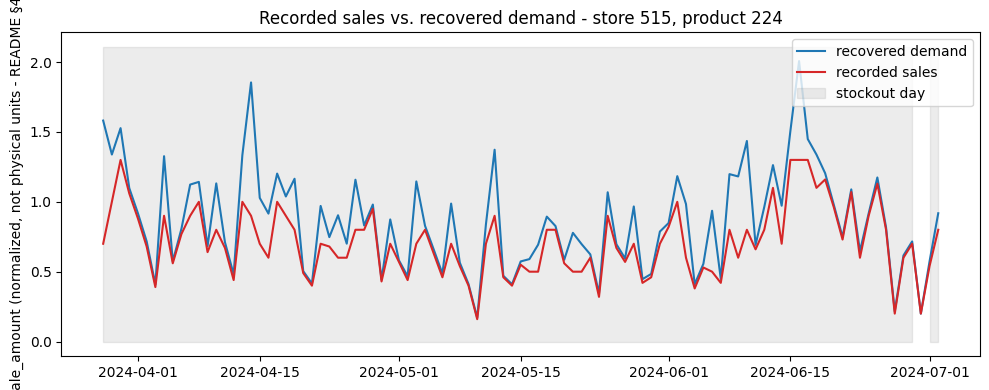

In [8]:
plots.plot_recovery_example(recovered, save_path=config.RECOVERY_PLOT)

### Does one multiplier still hold weeks later?

`bias_correction` is one number, fitted on full-shelf days inside the training window, then applied
to every recovered hour out to the test week. `recovered_demand` is what the forecaster trains on, so
a multiplier that drifts tilts the target further the later the day, and every score downstream
inherits the tilt while still looking clean.

Refit it in each window. Full-shelf days only, all held out of the fit, so the calendar is the only
thing changing between rows.

In [9]:
RUN_CORRECTION_CHECK = False   # refits Stage 1 per window; off = load the saved CSV

(recovery.correction_by_period(daily) if RUN_CORRECTION_CHECK
 else saved(config.CORRECTION_BY_PERIOD, "RUN_CORRECTION_CHECK"))

,n_clean_days,correction,shipped_is_off_by_%
period,,,
training,5000.0,0.8919,0.9216
validation,5000.0,0.8574,4.9791
calibration,5000.0,0.9234,-2.5213


**Result.** The shipped correction stays close to one refitted inside each window, and the deviation
is not monotone - one window sits above, another below. It moves; it does not drift. So a single
multiplier is sound and needs no per-period patching.

This mattered because `recovered_demand` is what the forecaster trains on: a correction that drifted
with the calendar would tilt the training target further the later the day, and every downstream
score would inherit the tilt while still looking clean. A check that could have failed and did not.

### Did anything leak?

Five mechanical checks, run on the same frames the pipeline fitted on - so a regression in the
training-pool filter is actually caught here.

In [10]:
RUN_LEAKAGE = False   # rebuilds the hourly frame; off = load the saved verdicts

if RUN_LEAKAGE:
    checks = splits.check_leakage(daily)
    config.LEAKAGE_CHECKS.write_text(json.dumps(checks, indent=2))
else:
    checks = json.loads(config.LEAKAGE_CHECKS.read_text())
    print(f"loaded saved verdicts: {sum(checks.values())}/{len(checks)} passed")

assert all(checks.values()), "leakage check failed - fix before trusting anything above"

loaded saved verdicts: 5/5 passed


## 6. Does recovery change the forecast?

One model - the strongest baseline - trained twice with the same settings and seed, once on raw sales
and once on recovered demand, each given the history it would really have. Both scored the same way:
per date, non-stockout validation rows, against recorded `sale_amount`.

Read it per band, never pooled. On the scored rows the two targets are identical, so pooled the
recovered twin can only look worse - it predicts demand and is marked down for exceeding recorded
sales. The question worth asking is whether it removes the under-forecast on the products that keep
selling out, and that can come back flat.

In [11]:
RUN_IMPACT = False   # off = load the saved CSV

impact = (baselines.recovery_impact(recovered) if RUN_IMPACT
          else pd.read_csv(config.RECOVERY_IMPACT, index_col=0, header=[0, 1]))
impact.round(4)

xgb_raw                                               \
              n_scored    WAPE     WPE     MAE pinball(avg)   CRPS~   
<25% censored   3955.0  0.4712  0.0195  0.3407       0.1082  0.2967   
25-50%         30345.0  0.3601  0.0078  0.2953       0.0945  0.2294   
50-75%         12319.0  0.3084 -0.0151  0.4272       0.1361  0.1950   
>=75%           1375.0  0.2875 -0.1964  0.8947       0.2948  0.1915   
ALL            47994.0  0.3423 -0.0187  0.3502       0.1121  0.2181   

              xgb_recovered                                               \
                   n_scored    WAPE     WPE     MAE pinball(avg)   CRPS~   
<25% censored        3955.0  0.4604  0.1162  0.3330       0.1081  0.2964   
25-50%              30345.0  0.3702  0.1129  0.3038       0.0970  0.2353   
50-75%              12319.0  0.3124  0.1120  0.4349       0.1384  0.1983   
>=75%                1375.0  0.2256  0.0013  0.6984       0.2252  0.1463   
ALL                 47994.0  0.3426  0.1014  0.3512       0.1122  0.2183   

                 gap  
              WAPE_%  
<25% censored  -2.29  
25-50%          2.80  
50-75%          1.30  
>=75%         -21.53  
ALL             0.09

**Result.** On products that sell out on 75%+ of days, the raw twin under-forecasts badly - it was
trained on sales that never happened. The recovered twin removes essentially all of that bias and is
**21.5% more accurate** on the same rows. That is measured against recorded sales, on days the shelf
never emptied, so no recovery assumption enters the scoring.

Pooled, the two are level. That is the paragraph above playing out rather than a contradiction: the
scored rows are exactly the rows where the two targets agree, so the pooled row cannot show the
effect in either direction. The cost of recovery is a mild over-forecast on the less-censored bands,
and the ordering stage has to earn that back.

The 75%+ band is the smallest in the table. The direction is clean and the mechanism is the predicted
one; treat the magnitude as indicative.

## Appendix - why models are ranked on daily totals, not on hours

Stage 1 predicts one hour at a time, so the obvious thing is to score it per hour. That does not work,
and it is worth one table to show why, because it is the first thing anyone asks.

Most hours sell nothing. So a model predicting zero everywhere is right on almost every hour and wrong
by exactly the actual amount on the rest - which scores **WAPE = 1.0000 exactly**, by construction. If
real models cannot clear that comfortably, the metric is rewarding *doing no recovery* and cannot rank
recovery models at all.

Nothing downstream reads this table. It exists to justify the choice made in step 3.

In [12]:
RUN_APPENDIX = False   # one fit per candidate; off = load the saved CSV

hour_level = (recovery.hour_level_table(daily) if RUN_APPENDIX
              else saved(config.HOUR_LEVEL_TABLE, "RUN_APPENDIX"))
hour_level

,wape,mae,wpe,fit_seconds
lightgbm_tweedie,0.9880,0.051800,-0.0164,130.1
xgboost,0.9920,0.052000,0.0014,175.0
lightgbm_l2,0.9987,0.052300,0.0011,77.3
lightgbm_poisson,1.0032,0.052600,-0.0012,112.1
series_hour_mean,1.0180,0.053300,-0.0020,1.9
poisson_glm,1.3722,0.071900,-0.0024,42.5
all_zeros,1.0000,0.052391,-1.0000,0.0


**Result.** The do-nothing predictor scores exactly 1.0000, several real candidates score **worse**
than that, and the best clears it by about one percent. So on this metric the entire distance between
"the best model available" and "predict nothing" is a single percentage point, and noise reorders the
table.

That is why step 3 ranks candidates on daily totals, where aggregating removes most of the zeros.